In [1]:
from transformers import AutoConfig, AutoTokenizer, BertTokenizer, BertForSequenceClassification, AutoModelForSequenceClassification, TrainingArguments, Trainer, pipeline
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, KFold
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, classification_report
import pandas as pd
import re
import ast
import numpy as np
import seaborn as sns
from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import wandb
from scipy.stats import entropy
import optuna
import spacy
import random
from optuna.samplers import GridSampler
from transformers import set_seed as hf_set_seed
import torch
from collections import Counter

In [10]:
top_1000 = (
    pd.read_csv('../../annotations/all_annotations.csv')
      .iloc[1:]
      .query('partition == "unlabeled" and flagged == "True"')
      .sort_values(by='entropy', ascending=False)
      .head(1000)
)

In [12]:
top_1000.to_csv("../../annotations/top1000.csv", index=False)

In [46]:
SEED = 42

# Python, NumPy, PyTorch seeds
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# HuggingFace helper
hf_set_seed(SEED)

In [4]:
annotations = pd.read_csv('../../annotations/final_final_final_goldlabels.csv')

In [5]:
annotations = annotations.reset_index(drop=False).rename(columns={'index': 'orig_index'}) ## add index to later restore again!:)

In [6]:
annotations
# 5783 overall (with interjections)

,orig_index,Filename,Period,Date,Speech #,Paragraph #,Speaker,Role,Gender,Party,...,Directed at (Person),Directed at (Party),Paragraph tokens,Interjection tokens,paragraph_token_count,interjection_token_count,Agenda Item,Context,Supplementary Context,Previous Interjections
0,0,20_0002.xml,20,11.11.2021,3,7,Franziska Brantner,NaN,weiblich,GRUENE,...,Franziska Brantner,GRUENE,NaN,"['So', 'ist', 'es']",0,3,"Migration ordnen, steuern und begrenzen – Neue...",a) Beratung des Antrags der Fraktion der CDU/C...,NaN,[]
1,1,20_0002.xml,20,11.11.2021,4,1,Till Mansmann,NaN,männlich,FDP,...,Till Mansmann,FDP,NaN,['Wahnsinn'],0,1,NaN,Erste Beratung des von der Bundesregierung ein...,NaN,[]
2,2,20_0002.xml,20,11.11.2021,4,3,Till Mansmann,NaN,männlich,FDP,...,Till Mansmann,FDP,NaN,"['Guter', 'Geschichtsunterricht']",0,2,NaN,Erste Beratung des von der Bundesregierung ein...,NaN,"[('Beifall', 'FDP', None)]"
3,3,20_0002.xml,20,11.11.2021,4,4,Till Mansmann,NaN,männlich,FDP,...,Till Mansmann,FDP,NaN,['Richtig'],0,1,NaN,Erste Beratung des von der Bundesregierung ein...,NaN,[]
4,4,20_0002.xml,20,11.11.2021,4,4,Till Mansmann,NaN,männlich,FDP,...,Till Mansmann,FDP,NaN,"['Genau', 'Richtig']",0,2,NaN,Erste Beratung des von der Bundesregierung ein...,NaN,"[('Zuruf', 'SPD', 'Richtig!')]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5778,5778,20_0214.xml,20,18.03.2025,28,16,Sonja Eichwede,NaN,weiblich,SPD,...,Sonja Eichwede,SPD,NaN,"['Das', 'mit', 'den', 'Zinsen', 'haben', 'Sie'...",0,8,Nein zur Kriegstüchtigkeit – Ja zur Diplomatie...,a) Zweite und dritte Beratung des von den Frak...,NaN,[]
5779,5779,20_0214.xml,20,18.03.2025,32,7,Jessica Rosenthal,NaN,weiblich,SPD,...,Jessica Rosenthal,SPD,NaN,"['Dann', 'gehen', 'Sie', 'in', 'den', 'Landtag']",0,6,Nein zur Kriegstüchtigkeit – Ja zur Diplomatie...,a) Zweite und dritte Beratung des von den Frak...,NaN,[]
5780,5780,20_0214.xml,20,18.03.2025,37,8,Dennis Rohde,NaN,männlich,SPD,...,Dennis Rohde,SPD,NaN,['Schleifen'],0,1,Nein zur Kriegstüchtigkeit – Ja zur Diplomatie...,a) Zweite und dritte Beratung des von den Frak...,NaN,"[('Beifall', 'SPD', None), ('Zuruf', 'AfD', 'I..."
5781,5781,20_0214.xml,20,18.03.2025,37,15,Dennis Rohde,NaN,männlich,SPD,...,Dennis Rohde,SPD,NaN,"['Zu', 'Schulden']",0,2,Nein zur Kriegstüchtigkeit – Ja zur Diplomatie...,a) Zweite und dritte Beratung des von den Frak...,NaN,[]


In [7]:
# Columns to ignore when comparing
ignore_cols = [
    'Interjection Text',
    'Interjection Label',
    'Topic Label',
    'interjection_token_count',
    'Interjection tokens',
    'Previous Interjections',
    'Interjector',
    'Interjector Gender',
    'Interjector Party',
    'Interjection type',
    'Directed at (Person)',
    'Directed at (Party)',
    'orig_index'
]


compare_cols = [col for col in annotations.columns if col not in ignore_cols]


In [8]:
annotations_individual = annotations.drop_duplicates(subset=compare_cols)

In [9]:
annotations_individual
# 5554 individual paragraphs

,orig_index,Filename,Period,Date,Speech #,Paragraph #,Speaker,Role,Gender,Party,...,Directed at (Person),Directed at (Party),Paragraph tokens,Interjection tokens,paragraph_token_count,interjection_token_count,Agenda Item,Context,Supplementary Context,Previous Interjections
0,0,20_0002.xml,20,11.11.2021,3,7,Franziska Brantner,NaN,weiblich,GRUENE,...,Franziska Brantner,GRUENE,NaN,"['So', 'ist', 'es']",0,3,"Migration ordnen, steuern und begrenzen – Neue...",a) Beratung des Antrags der Fraktion der CDU/C...,NaN,[]
1,1,20_0002.xml,20,11.11.2021,4,1,Till Mansmann,NaN,männlich,FDP,...,Till Mansmann,FDP,NaN,['Wahnsinn'],0,1,NaN,Erste Beratung des von der Bundesregierung ein...,NaN,[]
2,2,20_0002.xml,20,11.11.2021,4,3,Till Mansmann,NaN,männlich,FDP,...,Till Mansmann,FDP,NaN,"['Guter', 'Geschichtsunterricht']",0,2,NaN,Erste Beratung des von der Bundesregierung ein...,NaN,"[('Beifall', 'FDP', None)]"
3,3,20_0002.xml,20,11.11.2021,4,4,Till Mansmann,NaN,männlich,FDP,...,Till Mansmann,FDP,NaN,['Richtig'],0,1,NaN,Erste Beratung des von der Bundesregierung ein...,NaN,[]
5,5,20_0002.xml,20,11.11.2021,4,5,Till Mansmann,NaN,männlich,FDP,...,Till Mansmann,FDP,NaN,"['So', 'ist', 'es']",0,3,NaN,Erste Beratung des von der Bundesregierung ein...,NaN,"[('Beifall', 'FDP', None), ('Beifall', 'SPD', ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5778,5778,20_0214.xml,20,18.03.2025,28,16,Sonja Eichwede,NaN,weiblich,SPD,...,Sonja Eichwede,SPD,NaN,"['Das', 'mit', 'den', 'Zinsen', 'haben', 'Sie'...",0,8,Nein zur Kriegstüchtigkeit – Ja zur Diplomatie...,a) Zweite und dritte Beratung des von den Frak...,NaN,[]
5779,5779,20_0214.xml,20,18.03.2025,32,7,Jessica Rosenthal,NaN,weiblich,SPD,...,Jessica Rosenthal,SPD,NaN,"['Dann', 'gehen', 'Sie', 'in', 'den', 'Landtag']",0,6,Nein zur Kriegstüchtigkeit – Ja zur Diplomatie...,a) Zweite und dritte Beratung des von den Frak...,NaN,[]
5780,5780,20_0214.xml,20,18.03.2025,37,8,Dennis Rohde,NaN,männlich,SPD,...,Dennis Rohde,SPD,NaN,['Schleifen'],0,1,Nein zur Kriegstüchtigkeit – Ja zur Diplomatie...,a) Zweite und dritte Beratung des von den Frak...,NaN,"[('Beifall', 'SPD', None), ('Zuruf', 'AfD', 'I..."
5781,5781,20_0214.xml,20,18.03.2025,37,15,Dennis Rohde,NaN,männlich,SPD,...,Dennis Rohde,SPD,NaN,"['Zu', 'Schulden']",0,2,Nein zur Kriegstüchtigkeit – Ja zur Diplomatie...,a) Zweite und dritte Beratung des von den Frak...,NaN,[]


In [10]:
topic_labels = annotations[annotations['Topic Label'].notna()]
topic_labels
# 1121 topic labels overall

,orig_index,Filename,Period,Date,Speech #,Paragraph #,Speaker,Role,Gender,Party,...,Directed at (Person),Directed at (Party),Paragraph tokens,Interjection tokens,paragraph_token_count,interjection_token_count,Agenda Item,Context,Supplementary Context,Previous Interjections
3,3,20_0002.xml,20,11.11.2021,4,4,Till Mansmann,NaN,männlich,FDP,...,Till Mansmann,FDP,NaN,['Richtig'],0,1,NaN,Erste Beratung des von der Bundesregierung ein...,NaN,[]
4,4,20_0002.xml,20,11.11.2021,4,4,Till Mansmann,NaN,männlich,FDP,...,Till Mansmann,FDP,NaN,"['Genau', 'Richtig']",0,2,NaN,Erste Beratung des von der Bundesregierung ein...,NaN,"[('Zuruf', 'SPD', 'Richtig!')]"
9,9,20_0002.xml,20,11.11.2021,9,6,Reinhard Houben,NaN,männlich,FDP,...,Reinhard Houben,FDP,NaN,"['Ich', 'habe', 'kein', 'Problem', 'damit']",0,5,Horizont erweitern – Kernenergie für umweltfre...,a) Beratung des Antrags der Abgeordneten Dr. R...,NaN,[]
24,24,20_0009.xml,20,16.12.2021,1,3,Christian Lindner,Bundesminister der Finanzen,männlich,FDP,...,Christian Lindner,FDP,NaN,"['Hört', 'Hört']",0,2,NaN,Erste Beratung des von der Bundesregierung ein...,NaN,[]
25,25,20_0009.xml,20,16.12.2021,3,17,Dennis Rohde,NaN,männlich,SPD,...,Dennis Rohde,SPD,NaN,"['Hört', 'Hört']",0,2,NaN,Erste Beratung des von der Bundesregierung ein...,NaN,"[('Beifall', 'SPD', None), ('Beifall', 'FDP', ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5755,5755,20_0213.xml,20,13.03.2025,5,6,Johannes Vogel,NaN,männlich,FDP,...,Johannes Vogel,FDP,NaN,"['Ganz', 'genau']",0,2,NaN,NaN,NaN,[]
5768,5768,20_0214.xml,20,18.03.2025,3,4,Britta Haßelmann,NaN,weiblich,GRUENE,...,Britta Haßelmann,GRUENE,NaN,"['So', 'ist', 'das']",0,3,Nein zur Kriegstüchtigkeit – Ja zur Diplomatie...,a) Zweite und dritte Beratung des von den Frak...,NaN,[]
5771,5771,20_0214.xml,20,18.03.2025,10,10,Franziska Brantner,NaN,weiblich,GRUENE,...,Franziska Brantner,GRUENE,NaN,"['Da', 'machen', 'Sie', 'mit']",0,4,Nein zur Kriegstüchtigkeit – Ja zur Diplomatie...,a) Zweite und dritte Beratung des von den Frak...,NaN,"[('Beifall', 'GRUENE', None)]"
5772,5772,20_0214.xml,20,18.03.2025,10,11,Franziska Brantner,NaN,weiblich,GRUENE,...,Franziska Brantner,GRUENE,NaN,"['Ihr', 'könnt', 'ja', 'mit', 'Nein', 'stimmen']",0,6,Nein zur Kriegstüchtigkeit – Ja zur Diplomatie...,a) Zweite und dritte Beratung des von den Frak...,NaN,"[('Beifall', 'GRUENE', None)]"


In [11]:
topic_labels_individual = annotations_individual[annotations_individual['Topic Label'].notna()]
topic_labels_individual["Paragraph"]
# 1033 topic label per paragraph

3       In aller Kürze: Wir müssen das jetzt in letzte...
9       Niemand möchte ein Kohlekraftwerk vor der Haus...
24      Eine andere Prognose war im Januar in einem Ga...
25      So hat der damalige stellvertretende Fraktions...
28      Der zweite wichtige Punkt ist von meinem Kolle...
                              ...                        
5755    Sie schlagen ja nicht mal vor, das alte NATO-2...
5768    Und um noch eins draufzusetzen, haben Sie sich...
5771    Das geht an die Crème de la Crème, während die...
5772    Lassen Sie mich auch klar sagen: Solche Steuer...
5778    Für mich steht fest: Endlich lösen wir den Inv...
Name: Paragraph, Length: 1033, dtype: object

In [12]:
unknown_labels_individual = annotations_individual[annotations_individual['Topic Label'].isna()]
unknown_labels_individual

,orig_index,Filename,Period,Date,Speech #,Paragraph #,Speaker,Role,Gender,Party,...,Directed at (Person),Directed at (Party),Paragraph tokens,Interjection tokens,paragraph_token_count,interjection_token_count,Agenda Item,Context,Supplementary Context,Previous Interjections
0,0,20_0002.xml,20,11.11.2021,3,7,Franziska Brantner,NaN,weiblich,GRUENE,...,Franziska Brantner,GRUENE,NaN,"['So', 'ist', 'es']",0,3,"Migration ordnen, steuern und begrenzen – Neue...",a) Beratung des Antrags der Fraktion der CDU/C...,NaN,[]
1,1,20_0002.xml,20,11.11.2021,4,1,Till Mansmann,NaN,männlich,FDP,...,Till Mansmann,FDP,NaN,['Wahnsinn'],0,1,NaN,Erste Beratung des von der Bundesregierung ein...,NaN,[]
2,2,20_0002.xml,20,11.11.2021,4,3,Till Mansmann,NaN,männlich,FDP,...,Till Mansmann,FDP,NaN,"['Guter', 'Geschichtsunterricht']",0,2,NaN,Erste Beratung des von der Bundesregierung ein...,NaN,"[('Beifall', 'FDP', None)]"
5,5,20_0002.xml,20,11.11.2021,4,5,Till Mansmann,NaN,männlich,FDP,...,Till Mansmann,FDP,NaN,"['So', 'ist', 'es']",0,3,NaN,Erste Beratung des von der Bundesregierung ein...,NaN,"[('Beifall', 'FDP', None), ('Beifall', 'SPD', ..."
6,6,20_0002.xml,20,11.11.2021,4,10,Till Mansmann,NaN,männlich,FDP,...,Till Mansmann,FDP,NaN,"['Sehr', 'richtig']",0,2,NaN,Erste Beratung des von der Bundesregierung ein...,NaN,[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5777,5777,20_0214.xml,20,18.03.2025,28,15,Sonja Eichwede,NaN,weiblich,SPD,...,Sonja Eichwede,SPD,NaN,"['Das', 'tun', 'wir', 'auch']",0,4,Nein zur Kriegstüchtigkeit – Ja zur Diplomatie...,a) Zweite und dritte Beratung des von den Frak...,NaN,"[('Beifall', 'SPD', None)]"
5779,5779,20_0214.xml,20,18.03.2025,32,7,Jessica Rosenthal,NaN,weiblich,SPD,...,Jessica Rosenthal,SPD,NaN,"['Dann', 'gehen', 'Sie', 'in', 'den', 'Landtag']",0,6,Nein zur Kriegstüchtigkeit – Ja zur Diplomatie...,a) Zweite und dritte Beratung des von den Frak...,NaN,[]
5780,5780,20_0214.xml,20,18.03.2025,37,8,Dennis Rohde,NaN,männlich,SPD,...,Dennis Rohde,SPD,NaN,['Schleifen'],0,1,Nein zur Kriegstüchtigkeit – Ja zur Diplomatie...,a) Zweite und dritte Beratung des von den Frak...,NaN,"[('Beifall', 'SPD', None), ('Zuruf', 'AfD', 'I..."
5781,5781,20_0214.xml,20,18.03.2025,37,15,Dennis Rohde,NaN,männlich,SPD,...,Dennis Rohde,SPD,NaN,"['Zu', 'Schulden']",0,2,Nein zur Kriegstüchtigkeit – Ja zur Diplomatie...,a) Zweite und dritte Beratung des von den Frak...,NaN,[]


In [ ]:
## Finetuning the model

In [2]:
# Load tokenizer
tokenizer = BertTokenizer.from_pretrained("hannahsteinbach/finetuned_parlBERT_phaseI")

# Load model
finetuned_parlbert = BertForSequenceClassification.from_pretrained("hannahsteinbach/finetuned_parlBERT_phaseI")

# Load config
config = AutoConfig.from_pretrained("hannahsteinbach/finetuned_parlBERT_phaseI")

# Get id2label and label2id
id2label = config.id2label
label2id = config.label2id
label_list = [label for idx, label in sorted(id2label.items())]

print("id2label:", id2label)
print("label2id:", label2id)


tokenizer_config.json: 0.00B [00:00, ?B/s]

C:\Users\hanna\miniconda3\envs\im2024\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\hanna\.cache\huggingface\hub\models--hannahsteinbach--finetuned_parlBERT_phaseI. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

id2label: {0: 'Macroeconomics', 1: 'Civil', 2: 'Health', 3: 'Agriculture', 4: 'Labor', 5: 'Education', 6: 'Environment', 7: 'Energy', 8: 'Immigration', 9: 'Transportation', 10: 'Law', 11: 'Social', 12: 'Housing', 13: 'Domestic', 14: 'Defense', 15: 'Technology', 16: 'Foreign', 17: 'International', 18: 'Government', 19: 'Public', 20: 'Culture'}
label2id: {'Agriculture': 3, 'Civil': 1, 'Culture': 20, 'Defense': 14, 'Domestic': 13, 'Education': 5, 'Energy': 7, 'Environment': 6, 'Foreign': 16, 'Government': 18, 'Health': 2, 'Housing': 12, 'Immigration': 8, 'International': 17, 'Labor': 4, 'Law': 10, 'Macroeconomics': 0, 'Public': 19, 'Social': 11, 'Technology': 15, 'Transportation': 9}


In [13]:
# Encode label
topic_labels_individual.loc[:, "Encoded Topic Label"] = topic_labels_individual["Topic Label"].map(label2id)

C:\Users\hanna\AppData\Local\Temp\ipykernel_652\782654079.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  topic_labels_individual.loc[:, "Encoded Topic Label"] = topic_labels_individual["Topic Label"].map(label2id)


In [14]:
def safe_literal_eval(x):
    '''transform string of lists into lists'''
    if not x or pd.isna(x):
        return []
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return []

topic_labels_individual["Previous Paragraphs"] = topic_labels_individual["Previous Paragraphs"].apply(safe_literal_eval)

C:\Users\hanna\AppData\Local\Temp\ipykernel_652\356545718.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  topic_labels_individual["Previous Paragraphs"] = topic_labels_individual["Previous Paragraphs"].apply(safe_literal_eval)


In [15]:
### preprocessing (umlaute)
def german_transliteration(text):
    def translit(s):
        return (s.replace("ä", "ae")
                 .replace("ö", "oe")
                 .replace("ü", "ue")
                 .replace("Ä", "Ae")
                 .replace("Ö", "Oe")
                 .replace("Ü", "Ue")
                 .replace("ß", "ss"))

    if isinstance(text, list):
        # If it's a list of strings
        return [translit(item) for item in text]
    elif isinstance(text, str):
        # If it's a single string
        return translit(text)
    else:
        # If it's something else (e.g., None), just return as is
        return text

columns_to_process = ["Paragraph", "Previous Paragraphs", "Supplementary Context", "Context", "Agenda Item"]

for col in columns_to_process:
    topic_labels_individual[f"{col}_encoded"] = topic_labels_individual[col].apply(german_transliteration)

# Remove custom stopwords for

nlp = spacy.load("de_core_news_md", disable=["parser", "ner", "textcat"])
nlp.max_length = 1500000

# Custom stopwords (all lowercase)
custom_stopwords = {
    "aktuelle", "stunde", "bundesregierung", "geschäftsbereich",
    "tagesordnungspunkt", "bundesministerium", "bundesministeriums", "bundestages",
    "befragung", "artikel", "änderung", "geschäftsordnung", "verordnung",
    "ausschuss", "antrag", "antrags", "bericht", "berichts", "fraktionen",
    "beratung", "fraktion", "abgeordneter", "beschlussempfehlung", "gesetzes",
    "entwurfs", "ausschusses", "liebe", "kolleginnen", "kollegen", "gesetz", "ich", "rufe", "zp",
    "vereinbarte", "debatte", "abgeordneten", "fortfahren", "anfrage", "drucksache",
}


# Columns to clean
columns_to_clean = ["Agenda Item", "Context", "Supplementary Context"]

# Function to clean text
def clean_text(text):
    doc = nlp(str(text))
    words = []
    for token in doc:
        token_lower = token.text.lower()
        # Conditions to skip token:
        if (
            token.is_stop
            or token.is_punct
            or token.is_space
            or token.like_num
            or token_lower in custom_stopwords
            or re.fullmatch(r'[\d\W_]+', token.text)
        ):
            continue
        words.append(token_lower)
    return " ".join(words)

for col in columns_to_clean:
  topic_labels_individual[f"{col}_preprocessed"] = topic_labels_individual[col].apply(clean_text)

C:\Users\hanna\AppData\Local\Temp\ipykernel_652\3342161926.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  topic_labels_individual[f"{col}_encoded"] = topic_labels_individual[col].apply(german_transliteration)
C:\Users\hanna\AppData\Local\Temp\ipykernel_652\3342161926.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  topic_labels_individual[f"{col}_encoded"] = topic_labels_individual[col].apply(german_transliteration)
C:\Users\hanna\AppData\Local\Temp\ipykernel_652\3342161926.py:25: SettingWithCopyW

In [16]:
topic_labels_individual["Encoded Topic Label"] = topic_labels_individual["Topic Label"].map(label2id)
docs = topic_labels_individual[["Date"]].drop_duplicates()

train_dev_docs, test_docs = train_test_split(docs, test_size=0.3, random_state=42)

train_docs, dev_docs = train_test_split(train_dev_docs, test_size=0.3, random_state=42)

train_df = topic_labels_individual.merge(train_docs, on=["Date"])
dev_df   = topic_labels_individual.merge(dev_docs, on=["Date"])
test_df  = topic_labels_individual.merge(test_docs, on=["Date"])

print(f"Train size: {len(train_df)}")
print(f"Dev size: {len(dev_df)}")
print(f"Test size: {len(test_df)}")

train_labels = train_df["Encoded Topic Label"].to_list()
dev_labels = dev_df["Encoded Topic Label"].to_list()
test_labels = test_df["Encoded Topic Label"].to_list()

Train size: 487
Dev size: 247
Test size: 299


C:\Users\hanna\AppData\Local\Temp\ipykernel_652\47075185.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  topic_labels_individual["Encoded Topic Label"] = topic_labels_individual["Topic Label"].map(label2id)


In [18]:
train_labels_named =  [id2label[i] for i in train_labels]
dev_labels_named = [id2label[i] for i in dev_labels]
final_train_labels_named = train_labels_named + dev_labels_named

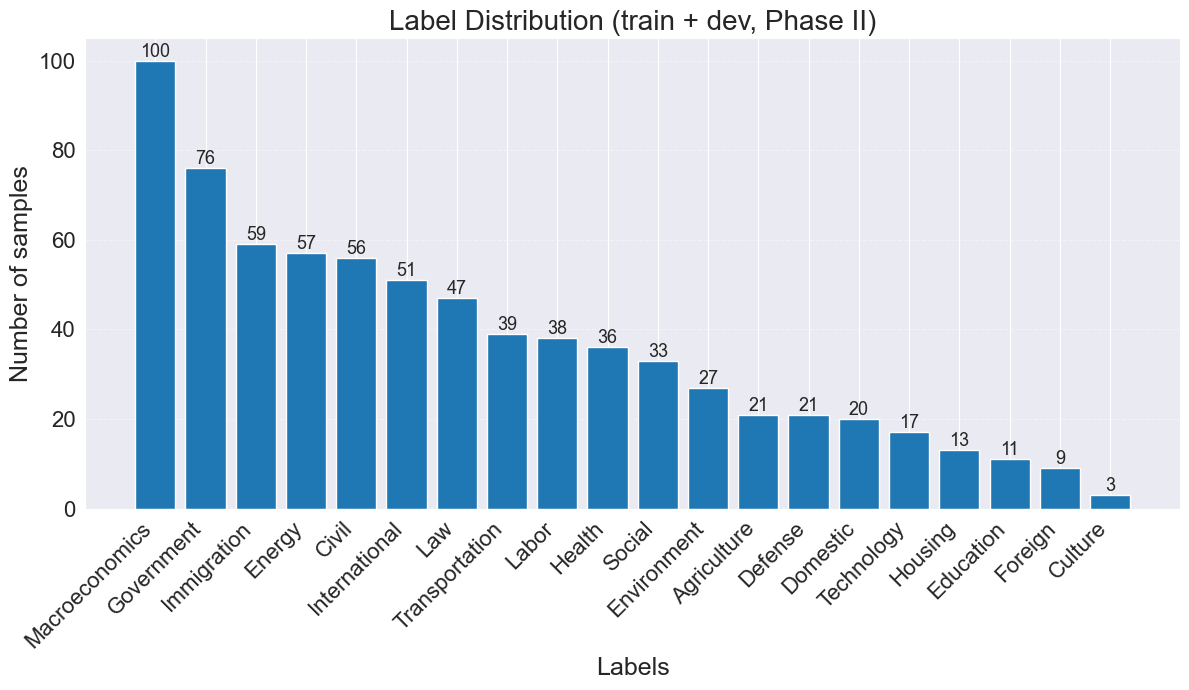

In [29]:
label_counts = Counter(final_train_labels_named)
labels, counts = zip(*sorted(label_counts.items(), key=lambda x: x[1], reverse=True))

x = np.arange(len(labels))

plt.figure(figsize=(12, 7))

bars = plt.bar(x, counts)

plt.xticks(x, labels, rotation=45, ha='right', fontsize=16)
plt.yticks(fontsize=16)
plt.ylabel("Number of samples", fontsize=18)
plt.xlabel("Labels", fontsize=18)
plt.title("Label Distribution (train + dev, Phase II)", fontsize=20)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha='center',
        va='bottom',
        fontsize=13
    )

# --- Grid & layout ---
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

# --- Save & show ---
plt.savefig('labeldis.png', bbox_inches="tight")
plt.show()

In [80]:
# -----------------------------
# 1. Tokenization function
# -----------------------------

def tokenize_multi_source(row, tokenizer, num_context=1, use_agenda_block=True, preprocess_agenda_block=True, max_length=256):
    """
    Tokenizes a single row with multiple sources: agenda, previous paragraphs, target paragraph.
    Keeps target at the end (segment_id=1), context/agenda at front (segment_id=0).

    Parameters:
        row: pd.Series, must contain 'Paragraph', 'Previous Paragraphs', 'Agenda Item', 'Context', 'Supplementary Context'
        tokenizer: HuggingFace tokenizer
        num_context: number of previous paragraphs to include
        use_agenda_block: include agenda/context/supplementary block if True
        max_length: max sequence length

    Returns:
        dict of input_ids, attention_mask, token_type_ids (all torch tensors)
    """
    # --- Previous paragraphs ---
    prev = row["Previous Paragraphs_encoded"]
    if isinstance(prev, str):
        prev = [prev]
    elif isinstance(prev, float) and pd.isna(prev):
        prev = []
    prev = prev[-num_context:] if num_context > 0 else []

    # --- Target paragraph ---
    target = str(row["Paragraph_encoded"]) if not pd.isna(row["Paragraph_encoded"]) else ""

    # --- Agenda block ---
    agenda_block = ""
    if use_agenda_block:
      if preprocess_agenda_block:
        agenda_block = " ".join(
            s for s in [row.get("Supplementary Context_preprocessed"), row.get("Context_preprocessed"), row.get("Agenda Item_preprocessed")]
            if pd.notna(s)
        )
      else:
        agenda_block = " ".join(
            s for s in [row.get("Supplementary Context_encoded"), row.get("Context_encoded"), row.get("Agenda Item_encoded")]
            if pd.notna(s)
        )

    # --- Combine sentences ---
    # Order: agenda/context first, previous paragraphs, target last
    all_sentences = []
    if agenda_block:
        all_sentences.append(agenda_block)
    all_sentences.extend(prev)
    all_sentences.append(target)

    # Join with [SEP]
    input_text = " [SEP] ".join(all_sentences)

    # Encode
    enc = tokenizer.encode_plus(
        input_text,
        add_special_tokens=True,
        truncation='only_first',  # truncate from front if too long
        padding='max_length',
        max_length=max_length,
        return_tensors='pt'
    )

    # --- token_type_ids ---
    # 0 for agenda/context/prev, 1 for target (last sentence)
    token_type_ids = []
    for idx, sentence in enumerate(all_sentences):
        length = len(tokenizer.tokenize(sentence))
        segment_id = 1 if idx == len(all_sentences) - 1 else 0
        token_type_ids.extend([segment_id] * length)
        token_type_ids.append(segment_id)  # for [SEP]

    # Add CLS at start
    token_type_ids = [0] + token_type_ids
    token_type_ids = (token_type_ids + [0]*max_length)[:max_length]

    return {
        "input_ids": enc["input_ids"].squeeze(),
        "attention_mask": enc["attention_mask"].squeeze(),
        "token_type_ids": torch.tensor(token_type_ids)
    }


def encode_dataframe(df, tokenizer, num_context, use_agenda_block, preprocess_agenda_block, max_length=256):
    all_input_ids = []
    all_attention = []
    all_token_types = []

    for _, row in df.iterrows():
        enc = tokenize_multi_source(
            row, tokenizer,
            num_context=num_context,
            use_agenda_block=use_agenda_block,
            preprocess_agenda_block=preprocess_agenda_block,
            max_length=max_length
        )
        all_input_ids.append(enc["input_ids"])
        all_attention.append(enc["attention_mask"])
        all_token_types.append(enc["token_type_ids"])

    return {
        "input_ids": torch.stack(all_input_ids),
        "attention_mask": torch.stack(all_attention),
        "token_type_ids": torch.stack(all_token_types),
    }


# -----------------------------
# 2. Dataset wrapper
# -----------------------------
class CustomDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

# -----------------------------
# 3. Metrics
# -----------------------------
def compute_metrics(eval_pred):
    """
    eval_pred: tuple (logits, labels)
        logits: raw model outputs (before softmax)
        labels: true class labels
    Returns:
        dict with f1_macro, f1_micro, f1_weighted, accuracy, auc_macro,
        avg_entropy, per_class_confidence
    """
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
    preds = np.argmax(probs, axis=-1)

    # --- Standard metrics ---
    f1_macro = f1_score(labels, preds, average="macro")
    f1_micro = f1_score(labels, preds, average="micro")
    f1_weighted = f1_score(labels, preds, average="weighted")
    accuracy = accuracy_score(labels, preds)

    # --- AUC ---
    try:
        auc_macro = roc_auc_score(labels, probs, multi_class="ovr", average="macro")
    except ValueError:
        auc_macro = float("nan")


    metrics = {
        "f1_macro": f1_macro,
        "f1_micro": f1_micro,
        "f1_weighted": f1_weighted,
        "accuracy": accuracy,
        "auc_macro": auc_macro,
    }

    return metrics


def model_init():
    model = BertForSequenceClassification.from_pretrained(
        "hannahsteinbach/finetuned_parlBERT_phaseI"
    )

    # Resize embeddings so BERT knows the new context tokens
    model.resize_token_embeddings(len(tokenizer))

    # Freeze first 8 layers (since we do not train the full model again)
    for param in model.bert.encoder.layer[:8].parameters():
        param.requires_grad = False

    return model



pruner = optuna.pruners.MedianPruner(n_startup_trials=2, n_warmup_steps=100)


# Use previous best hyperparameters
training_args = TrainingArguments(
    output_dir="./results_final",
    save_strategy="epoch",
    eval_strategy="epoch",
    learning_rate=2.672669365772627e-05,
    per_device_train_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.014810009452270324,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro"
)

In [81]:
def objective(
    trial, train_df, train_labels, dev_df, dev_labels,
    tokenizer, training_args, model_init, compute_metrics,
    max_length=256
):

    # --- Hyperparameters to tune ---
    use_agenda_block = trial.suggest_categorical("use_agenda_block", [True, False])
    if use_agenda_block:
        preprocess_agenda_block = trial.suggest_categorical("preprocess_agenda_block", [True, False])
    else:
        preprocess_agenda_block = False
    num_context = trial.suggest_int("num_context", 0, 2)

    # --- Tokenization ---
    train_enc = encode_dataframe(
        train_df, tokenizer,
        num_context=num_context,
        use_agenda_block=use_agenda_block,
        preprocess_agenda_block=preprocess_agenda_block,
        max_length=max_length
    )
    dev_enc = encode_dataframe(
        dev_df, tokenizer,
        num_context=num_context,
        use_agenda_block=use_agenda_block,
        preprocess_agenda_block=preprocess_agenda_block,
        max_length=max_length
    )

    train_dataset = Dataset.from_dict({
        "input_ids": train_enc["input_ids"],
        "attention_mask": train_enc["attention_mask"],
        "token_type_ids": train_enc["token_type_ids"],
        "labels": torch.tensor(train_labels)
    })
    dev_dataset = Dataset.from_dict({
        "input_ids": dev_enc["input_ids"],
        "attention_mask": dev_enc["attention_mask"],
        "token_type_ids": dev_enc["token_type_ids"],
        "labels": torch.tensor(dev_labels)
    })

    # --- Trainer ---
    trainer = Trainer(
      args=training_args,
      train_dataset=train_dataset,
      eval_dataset=dev_dataset,
      tokenizer=tokenizer,
      model_init=model_init,
      compute_metrics=compute_metrics
  )


    trainer.train()
    load_best_model_at_end = True
    metric_for_best_model = "f1_macro"
    greater_is_better = True

    metrics = trainer.evaluate()
    return metrics["eval_f1_macro"]


In [82]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

In [ ]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(
    lambda trial: objective(
        trial,
        train_df=train_df,
        train_labels=train_labels,
        dev_df=dev_df,
        dev_labels=dev_labels,
        tokenizer=tokenizer,
        training_args=training_args,
        model_init=model_init,
        compute_metrics=compute_metrics,
        max_length=256
    ), n_trials=10
)

[I 2025-12-15 15:06:05,923] A new study created in memory with name: no-name-c63f9000-3e67-4168-bbb6-272a85999f42
/tmp/ipython-input-3246224434.py:45: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Find your API key here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Curre

Epoch,Training Loss,Validation Loss,F1 Macro,F1 Micro,F1 Weighted,Accuracy,Auc Macro
1,No log,1.467270,0.624593,0.659919,0.667919,0.659919,nan
2,No log,1.335967,0.646808,0.672065,0.681801,0.672065,nan
3,No log,1.335137,0.645993,0.676113,0.684278,0.676113,nan


[I 2025-12-15 15:09:09,062] Trial 0 finished with value: 0.6468075269376854 and parameters: {'use_agenda_block': False, 'num_context': 2}. Best is trial 0 with value: 0.6468075269376854.
/tmp/ipython-input-3246224434.py:45: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Micro,F1 Weighted,Accuracy,Auc Macro
1,No log,1.337542,0.613195,0.684211,0.683819,0.684211,nan
2,No log,1.224152,0.626968,0.704453,0.698592,0.704453,nan
3,No log,1.223149,0.624793,0.696356,0.692325,0.696356,nan


[I 2025-12-15 15:12:28,650] Trial 1 finished with value: 0.6269675368755043 and parameters: {'use_agenda_block': True, 'preprocess_agenda_block': True, 'num_context': 2}. Best is trial 0 with value: 0.6468075269376854.
/tmp/ipython-input-3246224434.py:45: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


...

Epoch,Training Loss,Validation Loss,F1 Macro,F1 Micro,F1 Weighted,Accuracy,Auc Macro
1,No log,1.290843,0.666807,0.712551,0.711793,0.712551,nan
2,No log,1.088389,0.670331,0.716599,0.717065,0.716599,nan
3,No log,1.079938,0.670234,0.712551,0.714238,0.712551,nan


[I 2025-12-15 15:33:17,446] Trial 8 finished with value: 0.6703313638572665 and parameters: {'use_agenda_block': True, 'preprocess_agenda_block': False, 'num_context': 2}. Best is trial 8 with value: 0.6703313638572665.
/tmp/ipython-input-3246224434.py:45: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Micro,F1 Weighted,Accuracy,Auc Macro
1,No log,1.261176,0.673588,0.700405,0.700017,0.700405,nan
2,No log,1.080958,0.703781,0.724696,0.724623,0.724696,nan
3,No log,1.072312,0.699892,0.720648,0.720062,0.720648,nan


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Micro,F1 Weighted,Accuracy,Auc Macro
1,No log,1.261176,0.673588,0.700405,0.700017,0.700405,nan
2,No log,1.080958,0.703781,0.724696,0.724623,0.724696,nan
3,No log,1.072312,0.699892,0.720648,0.720062,0.720648,nan


[I 2025-12-15 15:36:25,952] Trial 9 finished with value: 0.7037805681439265 and parameters: {'use_agenda_block': True, 'preprocess_agenda_block': False, 'num_context': 1}. Best is trial 9 with value: 0.7037805681439265.


In [ ]:
print("Best trial:")
best_trial = study.best_trial

print(f"  Value (F1 macro): {best_trial.value}")
print("  Params:")
for key, value in best_trial.params.items():
    print(f"    {key}: {value}")

Best trial:
  Value (F1 macro): 0.7037805681439265
  Params:
    use_agenda_block: True
    preprocess_agenda_block: False
    num_context: 1


In [ ]:
### Train on train + dev and evaluate on test set

In [83]:
train_dev_texts = pd.concat([train_df, dev_df], ignore_index=True)
train_dev_labels = train_labels + dev_labels

In [84]:
best_num_context=1
use_agenda_block=True
preprocess_agenda_block=False

In [85]:
train_dev_model = BertForSequenceClassification.from_pretrained(
    "hannahsteinbach/finetuned_parlBERT_phaseI"
)

# Freeze first 8 layers like before
for param in train_dev_model.bert.encoder.layer[:8].parameters():
    param.requires_grad = False

In [86]:
# --- Create dataset ---
train_dev_enc = encode_dataframe(
    train_dev_texts, tokenizer,
    num_context=best_num_context,
    use_agenda_block=use_agenda_block,
    preprocess_agenda_block=preprocess_agenda_block,
    max_length=256
)

train_dev_dataset = Dataset.from_dict({
    "input_ids": train_dev_enc["input_ids"],
    "attention_mask": train_dev_enc["attention_mask"],
    "token_type_ids": train_dev_enc["token_type_ids"],
    "labels": torch.tensor(train_dev_labels)
})

# --- Trainer ---
training_args = TrainingArguments(
    output_dir="./results_final_final",
    save_strategy="epoch",
    learning_rate=2.672669365772627e-05,
    per_device_train_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.014810009452270324,
)

trainer = Trainer(
    model=train_dev_model,
    args=training_args,
    train_dataset=train_dev_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

# --- Train ---
trainer.train()


/tmp/ipython-input-1988347472.py:27: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


TrainOutput(global_step=276, training_loss=1.0391420005024343, metrics={'train_runtime': 139.7384, 'train_samples_per_second': 15.758, 'train_steps_per_second': 1.975, 'total_flos': 289734690327552.0, 'train_loss': 1.0391420005024343, 'epoch': 3.0})

Final testing + entropy threshold  using MC dropout

In [87]:
test_enc = encode_dataframe(
    test_df, tokenizer,
    num_context=best_num_context,
    use_agenda_block=use_agenda_block,
    preprocess_agenda_block=preprocess_agenda_block,
    max_length=256
)

test_dataset = Dataset.from_dict({
    "input_ids": test_enc["input_ids"],
    "attention_mask": test_enc["attention_mask"],
    "token_type_ids": test_enc["token_type_ids"],
    "labels": torch.tensor(test_labels)
})

In [88]:
num_classes = len(id2label)

In [110]:
# ----------------------------
#  Compute predictive entropy
# ----------------------------
def compute_entropy(probs):
    """Compute predictive entropy for each sample (raw values, no scaling)."""
    entropy = -torch.sum(probs * torch.log(probs + 1e-12), dim=-1)
    return entropy


trainer.model.eval()
preds_test = trainer.predict(test_dataset)
logits_test = torch.tensor(preds_test.predictions, dtype=torch.float32)
probs_test = torch.softmax(logits_test, dim=-1)

pred_labels = probs_test.argmax(dim=1).numpy()
entropy_test = compute_entropy(probs_test)


Entropy threshold determined from test set: 0.34590


In [113]:
test_df['entropy'] = entropy_test.numpy()
test_df['prediction'] =  [id2label[i] for i in pred_labels]
test_df['correct'] = (test_df['prediction'] == test_df['Topic Label']).astype(int)

In [ ]:
### merge labels

In [114]:
merge_map = {'International': 'Int_Def',
    'Defense': 'Int_Def',
    'Macroeconomics': 'Macro_Dom',
    'Domestic': 'Macro_Dom',
    'Social': 'Soc_Labor',
    'Labor': 'Soc_Labor',
    'Technology': 'Tech_Trans',
    'Transportation': 'Tech_Trans',
    'Civil': 'Civ_Law_Im',
    'Law': 'Civ_Law_Im',
    'Immigration': 'Civ_Law_Im',
    'Energy': 'En_En',
    'Environment': 'En_En',
    'Health': 'Health',
    'Government': 'Government',
     'Education':  'Education', 'Agriculture':'Agriculture', 'Foreign':'Foreign', 'Housing':'Housing', 'Public':'Public', 'Culture':'Culture'}

test_df['merged_true'] = test_df['Topic Label'].map(merge_map).fillna(test_df['Topic Label'])

test_df['merged_pred'] = test_df['prediction'].map(merge_map).fillna(test_df['prediction'])

test_df['merged_correct'] = (
    test_df['merged_true'] == test_df['merged_pred']
).astype(int)

In [117]:
pred_labels  = pred_labels.tolist()

In [118]:
f1_macro = f1_score(test_labels, pred_labels, average='macro')
f1_micro = f1_score(test_labels, pred_labels, average='micro')
f1_weighted= f1_score(test_labels, pred_labels, average='weighted')

print("F1-Macro on test set:", f1_macro)
print("F1-Micro on test set:", f1_micro)
print("F1 weighted:", f1_weighted)

print(classification_report(
    [id2label[i] for i in test_labels],
    [id2label[i] for i in pred_labels]
))

F1-Macro on test set: 0.7055626769836094
F1-Micro on test set: 0.7090301003344481
F1 weighted: 0.7071077314979125
                precision    recall  f1-score   support

   Agriculture       0.77      0.77      0.77        13
         Civil       0.50      0.56      0.53        16
       Defense       0.61      0.79      0.69        14
      Domestic       0.80      1.00      0.89         4
     Education       0.86      0.86      0.86         7
        Energy       0.97      0.83      0.90        36
   Environment       0.62      0.91      0.74        11
       Foreign       0.50      1.00      0.67         1
    Government       0.64      0.57      0.60        37
        Health       0.92      0.73      0.81        15
       Housing       0.67      0.33      0.44         6
   Immigration       0.79      0.61      0.69        18
 International       0.62      0.59      0.60        22
         Labor       0.73      0.73      0.73        15
           Law       0.76      0.54      0.63

In [119]:
test_labels_named = [id2label[i] for i in test_labels]
pred_labels_named =  [id2label[i] for i in pred_labels]

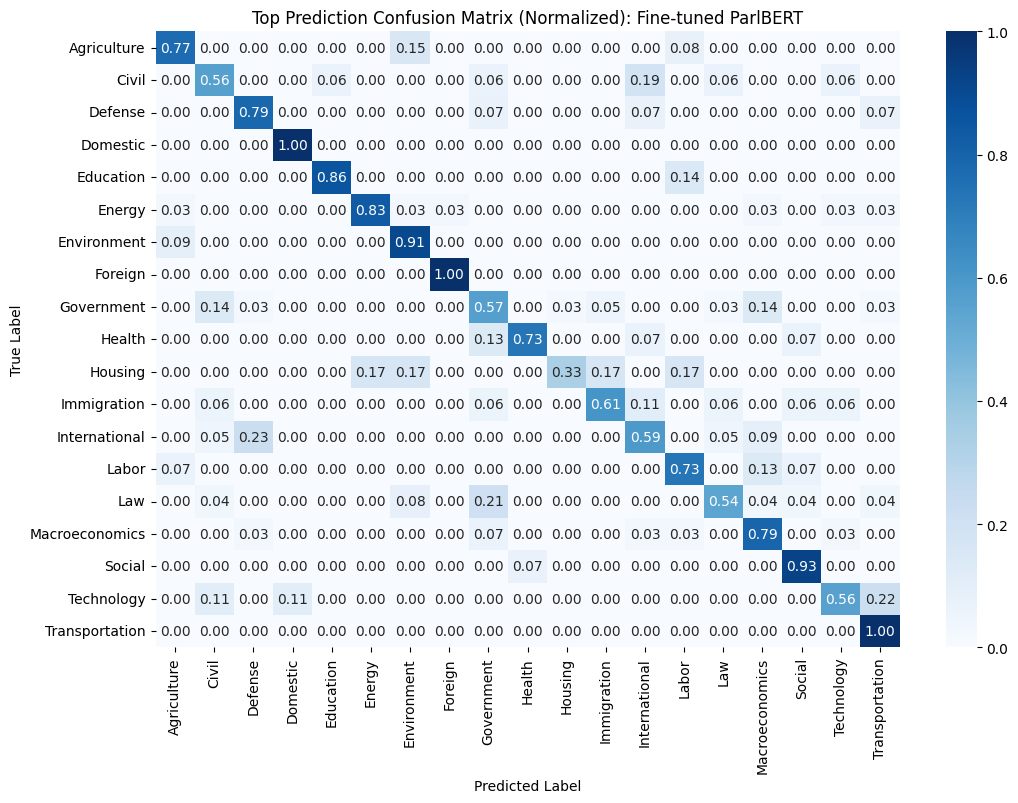

In [120]:
confusion_top = pd.crosstab(
    test_labels_named,
    pred_labels_named,
    rownames=['True Label'],
    colnames=['Predicted Label'],
    normalize='index'
)

plt.figure(figsize=(12,8))
sns.heatmap(confusion_top, annot=True, fmt=".2f", cmap="Blues")
plt.title("Top Prediction Confusion Matrix (Normalized): Fine-tuned ParlBERT")
plt.show()

In [ ]:
# Final Final Testing

In [123]:
final_df = pd.concat([train_df, dev_df, test_df], ignore_index=True)
final_labels = train_labels + dev_labels + test_labels
best_num_context=1
use_agenda_block=True
preprocess_agenda_block=False

In [ ]:
final_df

,Filename,Period,Date,Speech #,Paragraph #,Speaker,Role,Gender,Party,Interjector Party,...,Supplementary Context_encoded,Context_encoded,Agenda Item_encoded,Agenda Item_preprocessed,Context_preprocessed,Supplementary Context_preprocessed,entropy,prediction,correct,flagged
0,20_0002.xml,20,11.11.2021,4,4,Till Mansmann,NaN,männlich,FDP,SPD,...,NaN,Erste Beratung des von der Bundesregierung ein...,NaN,nan,eingebrachten umsetzung unionsrechtlicher vorg...,nan,NaN,NaN,NaN,NaN
1,20_0002.xml,20,11.11.2021,9,6,Reinhard Houben,NaN,männlich,FDP,GRUENE,...,NaN,a) Beratung des Antrags der Abgeordneten Dr. R...,Horizont erweitern – Kernenergie fuer umweltfr...,horizont erweitern kernenergie umweltfreundlic...,dr. rainer kraft karsten hilse marc bernhard w...,nan,NaN,NaN,NaN,NaN
2,20_0009.xml,20,16.12.2021,1,3,Christian Lindner,Bundesminister der Finanzen,männlich,FDP,FDP,...,NaN,Erste Beratung des von der Bundesregierung ein...,NaN,nan,eingebrachten feststellung nachtrags bundeshau...,nan,NaN,NaN,NaN,NaN
3,20_0009.xml,20,16.12.2021,3,17,Dennis Rohde,NaN,männlich,SPD,SPD,...,NaN,Erste Beratung des von der Bundesregierung ein...,NaN,nan,eingebrachten feststellung nachtrags bundeshau...,nan,NaN,NaN,NaN,NaN
4,20_0009.xml,20,16.12.2021,8,7,Lars Castellucci,NaN,männlich,SPD,GRUENE,...,NaN,Beratung des Antrags der Fraktion der CDU/CSU,Internationales Engagement fuer das Menschenre...,internationales engagement menschenrecht relig...,cdu/csu,nan,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1028,20_0212.xml,20,11.02.2025,4,65,Christian Lindner,NaN,männlich,FDP,FDP,...,NaN,Vereinbarte Debatte:,Zur Situation in Deutschland,situation deutschland,,nan,0.019789,Civil,1.0,False
1029,20_0212.xml,20,11.02.2025,6,9,Lars Klingbeil,NaN,männlich,SPD,FDP,...,NaN,Vereinbarte Debatte:,Zur Situation in Deutschland,situation deutschland,,nan,0.747589,Social,1.0,True
1030,20_0212.xml,20,11.02.2025,6,10,Lars Klingbeil,NaN,männlich,SPD,FDP,...,NaN,Vereinbarte Debatte:,Zur Situation in Deutschland,situation deutschland,,nan,2.140302,Social,1.0,True
1031,20_0212.xml,20,11.02.2025,6,32,Lars Klingbeil,NaN,männlich,SPD,FDP,...,NaN,Vereinbarte Debatte:,Zur Situation in Deutschland,situation deutschland,,nan,0.024028,Social,1.0,False


In [124]:
final_df = pd.concat([train_df, dev_df, test_df], ignore_index=True)
final_labels = train_labels + dev_labels + test_labels
best_num_context=1
use_agenda_block=True
preprocess_agenda_block=False

final_enc = encode_dataframe(
    final_df, tokenizer,
    num_context=best_num_context,
    use_agenda_block=use_agenda_block,
    preprocess_agenda_block=preprocess_agenda_block,
    max_length=256
)

final_dataset = Dataset.from_dict({
    "input_ids": final_enc["input_ids"],
    "attention_mask": final_enc["attention_mask"],
    "token_type_ids": final_enc["token_type_ids"],
    "labels": torch.tensor(final_labels)
})

final_model = BertForSequenceClassification.from_pretrained(
    "hannahsteinbach/finetuned_parlBERT_phaseI"
)

# Freeze first 8 layers like before
for param in final_model.bert.encoder.layer[:8].parameters():
    param.requires_grad = False


# --- Trainer ---
training_args = TrainingArguments(
    output_dir="./results_final_final",
    save_strategy="no",
    learning_rate=2.672669365772627e-05,
    per_device_train_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.014810009452270324,
)

trainer = Trainer(
    model=final_model,
    args=training_args,
    train_dataset=final_dataset,
    tokenizer=tokenizer
)

# --- Train ---
trainer.train()

trainer.save_model("./final_model")
tokenizer.save_pretrained("./final_model")


/tmp/ipython-input-964353100.py:41: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


('./final_model/tokenizer_config.json',
 './final_model/special_tokens_map.json',
 './final_model/vocab.txt',
 './final_model/added_tokens.json')

In [125]:
!zip -r /content/final_model.zip /content/final_model

  adding: content/final_model/ (stored 0%)
  adding: content/final_model/tokenizer_config.json (deflated 75%)
  adding: content/final_model/special_tokens_map.json (deflated 80%)
  adding: content/final_model/config.json (deflated 58%)
  adding: content/final_model/vocab.txt (deflated 57%)
  adding: content/final_model/training_args.bin (deflated 53%)
  adding: content/final_model/model.safetensors (deflated 7%)


In [ ]:
# predict unknown labels

In [ ]:
# ä -> ae

In [126]:
columns_to_process = ["Paragraph", "Previous Paragraphs", "Supplementary Context", "Context", "Agenda Item"]

for col in columns_to_process:
    unknown_labels_individual[f"{col}_encoded"] = unknown_labels_individual[col].apply(german_transliteration)

/tmp/ipython-input-931613379.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unknown_labels_individual[f"{col}_encoded"] = unknown_labels_individual[col].apply(german_transliteration)
/tmp/ipython-input-931613379.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unknown_labels_individual[f"{col}_encoded"] = unknown_labels_individual[col].apply(german_transliteration)
/tmp/ipython-input-931613379.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using

In [127]:
unknown_labels_individual['Previous Paragraphs']

,Previous Paragraphs
0,"['Wir sind anders als Lukaschenko, und das müs..."
1,[]
2,['Sehr geehrte Frau Präsidentin! Geschätzte Ko...
5,"['2013 wurden die Wurzeln im BMF gelegt, das d..."
6,"['Ein anderes, auch ergänzendes Instrument kan..."
...,...
5777,['Wir leben in einer sich dramatisch verändern...
5779,"['Angesichts all der Herausforderungen, vor de..."
5780,"['Wer jetzt noch glaubt, dass Stillstand die s..."
5781,"['Weil das so ist, braucht eine wehrhafte Demo..."


In [128]:
best_num_context=1
use_agenda_block=True
preprocess_agenda_block=False

unknown_enc = encode_dataframe(
    unknown_labels_individual, tokenizer,
    num_context=best_num_context,
    use_agenda_block=use_agenda_block,
    preprocess_agenda_block=preprocess_agenda_block,
    max_length=256
)

unknown_dataset = Dataset.from_dict({
    "input_ids": unknown_enc["input_ids"],
    "attention_mask": unknown_enc["attention_mask"],
    "token_type_ids": unknown_enc["token_type_ids"]
})

In [129]:
# Get predictions (logits) from your trainer
trainer.model.eval()
preds_final = trainer.predict(unknown_dataset)
logits_final = torch.tensor(preds_final.predictions, dtype=torch.float32)
probs_final = torch.softmax(logits_final, dim=-1)

preds_final = probs_final.argmax(dim=1).numpy()
entropy_final = compute_entropy(probs_final)

In [130]:
unknown_labels_individual['entropy'] = entropy_final
unknown_labels_individual['prediction'] =  [id2label[i] for i in preds_final]
unknown_labels_individual['correct'] = (unknown_labels_individual['prediction'] == unknown_labels_individual['Topic Label']).astype(int)
unknown_labels_individual['flagged'] = unknown_labels_individual['entropy'] >= 0.346

/tmp/ipython-input-763731927.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unknown_labels_individual['entropy'] = entropy_final
/tmp/ipython-input-763731927.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unknown_labels_individual['prediction'] =  [id2label[i] for i in preds_final]
/tmp/ipython-input-763731927.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentatio

In [131]:
unknown_labels_individual.to_csv('review_predictions.csv', index=False)

In [132]:
unknown_labels_individual["partition"] = "unlabeled"
train_df["partition"] = "train"
dev_df["partition"] = "dev"
test_df["partition"] = "test"

/tmp/ipython-input-1936100402.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unknown_labels_individual["partition"] = "unlabeled"


In [133]:
train_df = train_df.drop_duplicates(subset='orig_index')
dev_df = dev_df.drop_duplicates(subset='orig_index')
test_df = test_df.drop_duplicates(subset='orig_index')
unknown_labels_individual = unknown_labels_individual.drop_duplicates(subset='orig_index')


In [134]:
train_df.columns

Index(['orig_index', 'Filename', 'Period', 'Date', 'Speech #', 'Paragraph #',
       'Speaker', 'Role', 'Gender', 'Party', 'Interjector Party',
       'Previous Paragraphs', 'Paragraph', 'Topic Label', 'Interjection Text',
       'Interjection Label', 'Interjection', 'Intervention', 'Quote',
       'Interjector', 'Interjector Gender', 'Verbal interjection',
       'Nonverbal interjection', 'Interjection type', 'Directed at (Person)',
       'Directed at (Party)', 'Paragraph tokens', 'Interjection tokens',
       'paragraph_token_count', 'interjection_token_count', 'Agenda Item',
       'Context', 'Supplementary Context', 'Previous Interjections',
       'Encoded Topic Label', 'Paragraph_encoded',
       'Previous Paragraphs_encoded', 'Supplementary Context_encoded',
       'Context_encoded', 'Agenda Item_encoded', 'Agenda Item_preprocessed',
       'Context_preprocessed', 'Supplementary Context_preprocessed',
       'partition'],
      dtype='object')

In [135]:
# Combine all splits
all_splits = pd.concat([train_df, dev_df, test_df, unknown_labels_individual], axis=0)

if 'orig_index' not in annotations.columns:
    annotations = annotations.reset_index().rename(columns={'index': 'orig_index'})

for df in [train_df, dev_df, test_df, unknown_labels_individual]:
    if 'orig_index' not in df.columns:
        df = df.reset_index().rename(columns={'index': 'orig_index'})

for col in all_splits.columns:
    if col != 'orig_index' and col not in annotations.columns:
        annotations[col] = pd.NA

annotations = annotations.set_index('orig_index')

for df in [train_df, dev_df, test_df, unknown_labels_individual]:
    df_indexed = df.set_index('orig_index')
    cols_to_update = [col for col in df_indexed.columns if col in annotations.columns]
    annotations.update(df_indexed[cols_to_update])

annotations = annotations.reset_index()


In [136]:
annotations.columns

Index(['orig_index', 'Filename', 'Period', 'Date', 'Speech #', 'Paragraph #',
       'Speaker', 'Role', 'Gender', 'Party', 'Interjector Party',
       'Previous Paragraphs', 'Paragraph', 'Topic Label', 'Interjection Text',
       'Interjection Label', 'Interjection', 'Intervention', 'Quote',
       'Interjector', 'Interjector Gender', 'Verbal interjection',
       'Nonverbal interjection', 'Interjection type', 'Directed at (Person)',
       'Directed at (Party)', 'Paragraph tokens', 'Interjection tokens',
       'paragraph_token_count', 'interjection_token_count', 'Agenda Item',
       'Context', 'Supplementary Context', 'Previous Interjections',
       'Encoded Topic Label', 'Paragraph_encoded',
       'Previous Paragraphs_encoded', 'Supplementary Context_encoded',
       'Context_encoded', 'Agenda Item_encoded', 'Agenda Item_preprocessed',
       'Context_preprocessed', 'Supplementary Context_preprocessed',
       'partition', 'entropy', 'prediction', 'correct', 'flagged',
       'me

In [137]:
annotations.to_csv('all_annotations.csv', index=True)